In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.simplefilter('ignore', ConvergenceWarning)

# StatsForecast (AutoARIMA)
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string


In [2]:
# ==== Params ====
DATA_PATH  = r'E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv'
SEASON_LEN = 7  # daily data -> weekly seasonality

# ==== Load ====
df = pd.read_csv(DATA_PATH)
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

# PM2.5 -> daily mean
y = df[['PM25']].resample('D').mean().asfreq('D')['PM25']

# Winsorize nhẹ (1% & 99%) để tránh outlier cực đoan
lo, hi = y.quantile([0.01, 0.99])
y_w = y.clip(lo, hi)

# Biến đổi log để ổn định phương sai
y_t = np.log1p(y_w)

# Split 80/20
cutoff = int(len(y_t) * 0.8)
train = y_t.iloc[:cutoff].copy()
test  = y_t.iloc[cutoff:].copy()

print("Train len:", len(train), "Test len:", len(test))


Train len: 584 Test len: 147


In [3]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    mask = denom != 0
    return 100 * np.mean(2.0 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask])

def kpis_frame(actual, forecast):
    # thực hiện ở thang gốc (undo log1p)
    actual_lin   = np.expm1(actual)
    forecast_lin = np.expm1(forecast)

    bias = (forecast_lin - actual_lin).mean()
    mae  = np.abs(forecast_lin - actual_lin).mean()
    rmse = np.sqrt(((forecast_lin - actual_lin)**2).mean())

    mean_actual = actual_lin.mean()
    return pd.DataFrame([{
        'Bias' : bias,
        'Bias%': bias / mean_actual * 100 if mean_actual != 0 else np.nan,
        'MAE'  : mae,
        'MAE%' : mae / mean_actual * 100 if mean_actual != 0 else np.nan,
        'RMSE' : rmse,
        'RMSE%': rmse / mean_actual * 100 if mean_actual != 0 else np.nan,
        'MAPE' : mape(actual_lin, forecast_lin),
        'sMAPE': smape(actual_lin, forecast_lin),
    }]).round(3)


d=0, D=0


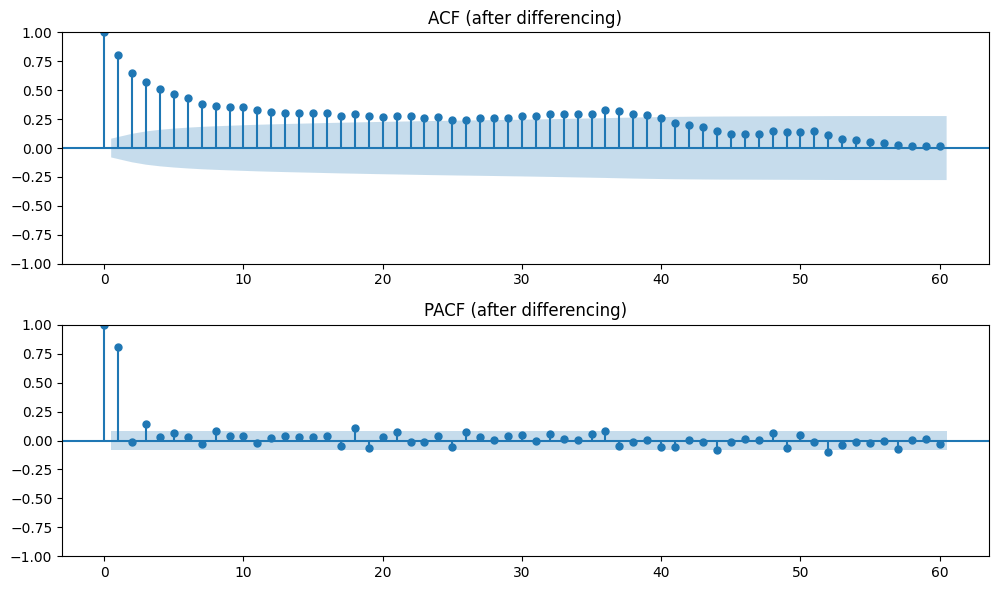

In [4]:
def ndiffs_adf(series, max_d=3):
    s = series.dropna().copy()
    for d in range(max_d+1):
        try:
            p = adfuller(s, autolag='AIC')[1]
        except Exception:
            p = 1.0
        if p < 0.05:
            return d
        s = s.diff().dropna()
    return max_d

def nsdiffs_stl(series, season_len=SEASON_LEN):
    s = series.dropna()
    if len(s) < 3*season_len:
        return 0
    stl = STL(s, period=season_len, robust=True).fit()
    seas, resid = stl.seasonal, stl.resid
    Fs = max(0.0, 1.0 - (np.var(resid, ddof=1) / max(np.var(resid+seas, ddof=1), 1e-9)))
    return 1 if Fs > 0.6 else 0

d = ndiffs_adf(train)
D = nsdiffs_stl(train, season_len=SEASON_LEN)
print(f"d={d}, D={D}")

# Plot ACF/PACF sau sai phân tương ứng
s = train.copy()
if d > 0: s = s.diff(d)
if D > 0: s = s.diff(SEASON_LEN)
s = s.dropna()

fig, ax = plt.subplots(2,1, figsize=(10,6))
plot_acf(s, lags=60, ax=ax[0]); ax[0].set_title('ACF (after differencing)')
plot_pacf(s, lags=60, ax=ax[1], method='ywm'); ax[1].set_title('PACF (after differencing)')
plt.tight_layout(); plt.show()


In [5]:
def sarima_grid_search(train_series, d, D, season_len=SEASON_LEN,
                       p_range=range(0,6), q_range=range(0,6),
                       P_range=range(0,3), Q_range=range(0,3),
                       max_params_ratio=0.12):
    n = len(train_series.dropna())
    best = None
    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    try:
                        fit = SARIMAX(train_series,
                                      order=(p,d,q),
                                      seasonal_order=(P,D,Q,season_len),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False).fit(disp=False)
                        k   = fit.params.shape[0]
                        if k > max(3, int(max_params_ratio*n)):  # chặn quá phức tạp
                            continue
                        aic = fit.aic
                        aicc = aic + (2*k*(k+1))/(n-k-1) if (n-k-1)>0 else np.inf
                        lag = season_len if season_len < n//2 else max(1, n//4)
                        lb_ok = (acorr_ljungbox(fit.resid.dropna(), lags=[lag], return_df=True)
                                 ["lb_pvalue"] > 0.05).all()
                        cand = (aicc, lb_ok, (p,d,q), (P,D,Q,season_len), fit)
                        if (best is None) or (cand[0] < best[0]) or (cand[0]==best[0] and cand[1] and not best[1]):
                            best = cand
                    except Exception:
                        continue
    if best is None:
        raise RuntimeError("No SARIMA fits succeeded.")
    print("Best AICc:", round(best[0],2), "| Ljung-Box OK:", best[1],
          "| orders:", best[2], "| seasonal:", best[3])
    return best


In [6]:
def forecast_and_plot(model_fit, train, test, steps):
    fc = model_fit.get_forecast(steps=steps).summary_frame()
    fc_mean = fc['mean']
    # plot trên thang gốc cho trực quan
    plt.figure(figsize=(12,5))
    plt.plot(np.expm1(train), label='Train')
    plt.plot(np.expm1(test),  label='Test', color='red')
    plt.plot(np.expm1(fc_mean), label='Forecast', color='green')
    plt.fill_between(fc.index, np.expm1(fc['mean_ci_lower']), np.expm1(fc['mean_ci_upper']),
                     alpha=0.25)
    plt.axvline(train.index[-1], linestyle='--', alpha=0.5, color='gray')
    plt.title(f"SARIMA Forecast ({steps} steps, ±95% CI)")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return fc_mean


In [7]:
def autoarima_statsforecast(train, test, season_len=SEASON_LEN):
    # StatsForecast format
    train_df = (train.reset_index()
                      .rename(columns={'Local Time':'ds', 0:'y'}) if 0 in train.index.names
                else train.reset_index().rename(columns={'Local Time':'ds', train.name:'y'}))
    train_df.columns = ['ds','y']

    test_df  = (test.reset_index()
                     .rename(columns={'Local Time':'ds', 0:'y'}) if 0 in test.index.names
               else test.reset_index().rename(columns={'Local Time':'ds', test.name:'y'}))
    test_df.columns = ['ds','y']

    train_df['ds'] = pd.to_datetime(train_df['ds'])
    test_df['ds']  = pd.to_datetime(test_df['ds'])

    sf = StatsForecast(models=[AutoARIMA(season_length=season_len)], freq='D', n_jobs=-1)
    fitted = sf.fit(train_df.assign(unique_id='series')[['unique_id','ds','y']])
    h = len(test_df)
    fc = fitted.predict(h=h)  # columns: unique_id, ds, AutoARIMA

    # in cấu trúc mô hình
    orders = fitted.fitted_[0][0]
    print("AutoARIMA structure:", arima_string(orders.model_))

    # plot trên thang gốc
    plt.figure(figsize=(12,5))
    plt.plot(train_df['ds'], np.expm1(train_df['y']), label='Train')
    plt.plot(test_df['ds'],  np.expm1(test_df['y']),  label='Test', color='red')
    plt.plot(fc['ds'],       np.expm1(fc['AutoARIMA']), label='Forecast', color='green')
    plt.axvline(train_df['ds'].max(), linestyle='--', alpha=0.5, color='gray')
    plt.title(f"StatsForecast AutoARIMA ({h} steps)")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    # trả về series log để so KPI thống nhất
    fc_series = pd.Series(fc['AutoARIMA'].values, index=pd.to_datetime(fc['ds']), name='autoarima_fc')
    return fc_series


AutoARIMA structure: ARIMA(2,1,2)(0,0,1)[7]                   


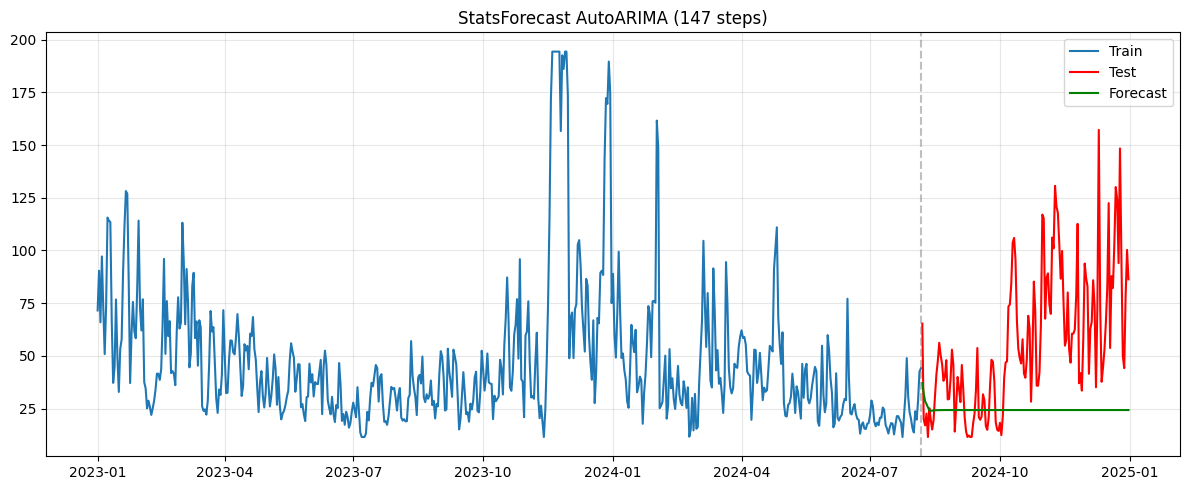

In [ ]:
# 1) AutoARIMA
auto_fc_log = autoarima_statsforecast(train, test, season_len=SEASON_LEN)

# 2) SARIMA grid-search
best = sarima_grid_search(train, d=d, D=D, season_len=SEASON_LEN)
sarima_fc_log = forecast_and_plot(best[4], train, test, steps=len(test))

# KPI so sánh (thang gốc)
print("KPI – SARIMA")
display(kpis_frame(test, sarima_fc_log))

print("KPI – AutoARIMA")
display(kpis_frame(test, auto_fc_log))
